In [ ]:
cd /mnt/hdd4/A_Nilay/ERA5_Daily_Prep_1980-2026
ls *.nc | head

In [ ]:
ncdump -h ERA5_Daily_Rainfall_1980.nc

/home/polar/.local/share/mamba/envs/geo_kernel/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


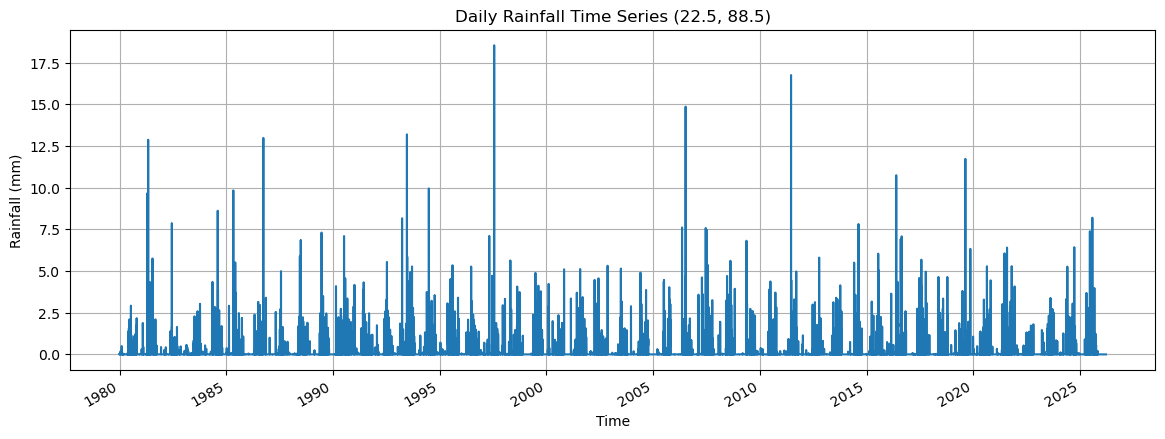


MISSING DATES
❌ Missing 11 dates

DatetimeIndex(['2026-01-25', '2026-01-26', '2026-01-27', '2026-01-28',
               '2026-01-29', '2026-01-30', '2026-01-31', '2026-02-25',
               '2026-02-26', '2026-02-27', '2026-02-28'],
              dtype='datetime64[ns]', freq=None)

✅ Done!


In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# FILE PATH
# ============================================
file_path = r"/mnt/hdd4/A_Nilay/ERA5_Daily_Prep_1980-2026/ERA5_merged_1980_2026.nc"

# ============================================
# OPEN DATASET (safe)
# ============================================
ds = xr.open_dataset(file_path)

# ============================================
# RENAME TIME (important)
# ============================================
ds = ds.rename({'valid_time': 'time'})

# ============================================
# SORT LATITUDE (important)
# ============================================
ds = ds.sortby('latitude')

# ============================================
# CONVERT TO mm
# ============================================
ds['tp'] = ds['tp'] * 1000
ds['tp'].attrs['units'] = 'mm'

# ============================================
# SELECT GRID POINT (CHANGE THIS)
# ============================================
lat = 22.5     # example (India region)
lon = 88.5

point = ds.sel(latitude=lat, longitude=lon, method='nearest')

# ============================================
# CONVERT TO PANDAS
# ============================================
ts = point['tp'].to_series()

# ============================================
# PLOT TIME SERIES
# ============================================
plt.figure(figsize=(14,5))
ts.plot()
plt.title(f"Daily Rainfall Time Series ({lat}, {lon})")
plt.xlabel("Time")
plt.ylabel("Rainfall (mm)")
plt.grid()
plt.show()

# ============================================
# FIND MISSING DATES
# ============================================

# Full expected range
full_range = pd.date_range(
    start=ts.index.min(),
    end=ts.index.max(),
    freq='D'
)

# Missing dates
missing_dates = full_range.difference(ts.index)

print("\n==============================")
print("MISSING DATES")
print("==============================")

if len(missing_dates) == 0:
    print("✅ No missing dates — dataset is continuous")
else:
    print(f"❌ Missing {len(missing_dates)} dates\n")
    print(missing_dates)

# ============================================
# OPTIONAL: SAVE MISSING DATES
# ============================================
missing_dates.to_series().to_csv("missing_dates.csv")

print("\n✅ Done!")

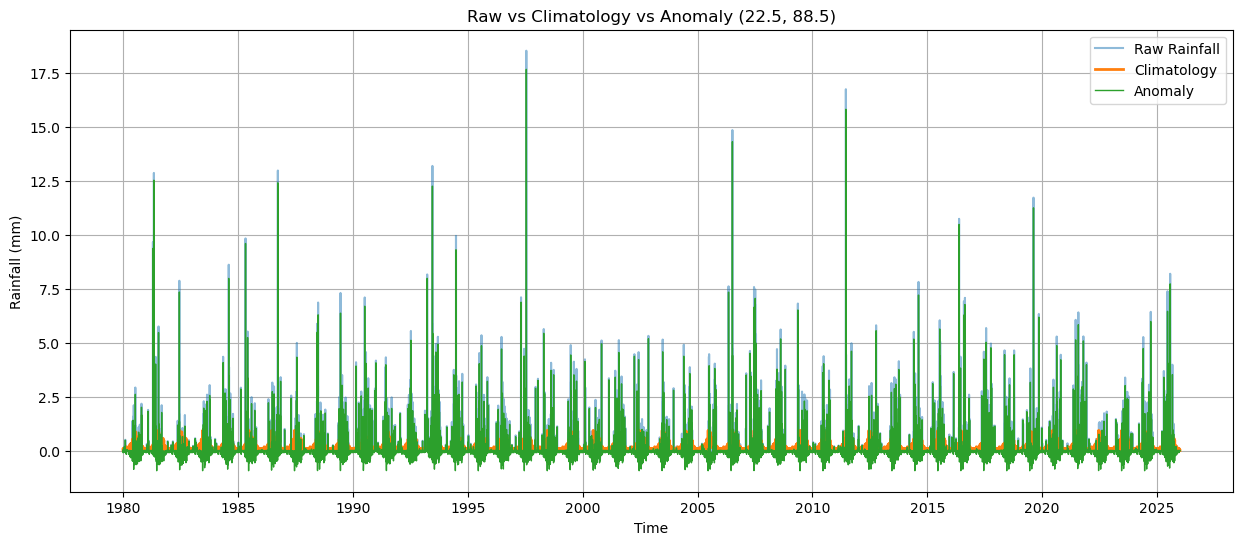

In [3]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

# ============================================
# FILE PATHS
# ============================================
raw_file  = r"/mnt/hdd4/A_Nilay/ERA5_Daily_Prep_1980-2026/ERA5_1980_2025.nc"
clim_file = r"/mnt/hdd4/A_Nilay/ERA5_Daily_Prep_1980-2026/climatology.nc"
anom_file = r"/mnt/hdd4/A_Nilay/ERA5_Daily_Prep_1980-2026/anomaly.nc"

# ============================================
# OPEN DATASETS
# ============================================
ds   = xr.open_dataset(raw_file).rename({'valid_time': 'time'})
clim = xr.open_dataset(clim_file).rename({'valid_time': 'time'})
anom = xr.open_dataset(anom_file).rename({'valid_time': 'time'})

# ============================================
# SORT LATITUDE
# ============================================
ds   = ds.sortby('latitude')
clim = clim.sortby('latitude')
anom = anom.sortby('latitude')

# ============================================
# CONVERT TO mm
# ============================================
ds['tp']   = ds['tp'] * 1000
clim['tp'] = clim['tp'] * 1000
anom['tp'] = anom['tp'] * 1000

# ============================================
# SELECT GRID POINT
# ============================================
lat = 22.5
lon = 88.5

raw_point  = ds.sel(latitude=lat, longitude=lon, method='nearest')
anom_point = anom.sel(latitude=lat, longitude=lon, method='nearest')
clim_point = clim.sel(latitude=lat, longitude=lon, method='nearest')

# ============================================
# CREATE DAYOFYEAR FOR CLIMATOLOGY
# ============================================
clim_point = clim_point.assign_coords(
    dayofyear=("time", range(1, len(clim_point.time) + 1))
)

# ============================================
# MATCH CLIMATOLOGY WITH REAL TIME
# ============================================
doy = raw_point['time'].dt.dayofyear

clim_matched = clim_point['tp'].sel(dayofyear=doy.values)

# ============================================
# CONVERT TO PANDAS
# ============================================
ts_raw  = raw_point['tp'].to_series()
ts_anom = anom_point['tp'].to_series()
ts_clim = pd.Series(clim_matched.values, index=ts_raw.index)

# ============================================
# PLOT COMPARISON
# ============================================
plt.figure(figsize=(15,6))

plt.plot(ts_raw.index, ts_raw, label="Raw Rainfall", alpha=0.5)
plt.plot(ts_clim.index, ts_clim, label="Climatology", linewidth=2)
plt.plot(ts_anom.index, ts_anom, label="Anomaly", linewidth=1)

plt.title(f"Raw vs Climatology vs Anomaly ({lat}, {lon})")
plt.xlabel("Time")
plt.ylabel("Rainfall (mm)")
plt.legend()
plt.grid()

plt.show()

# ============================================
# OPTIONAL: ZOOM INTO A PERIOD (MJO SCALE)
# ============================================
# Uncomment to zoom
# plt.xlim("2000-01-01", "2002-12-31")
# plt.show()

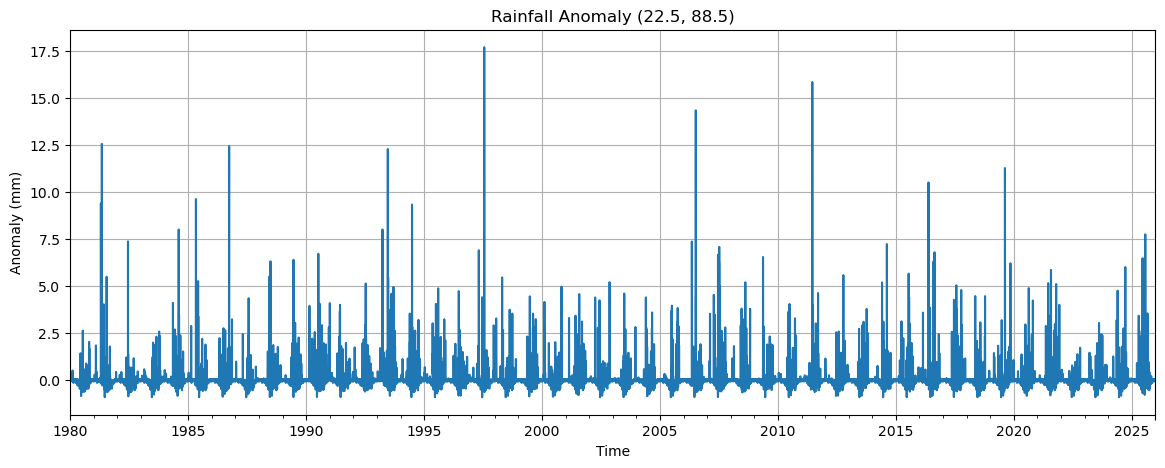

In [4]:
import xarray as xr
import matplotlib.pyplot as plt

# ============================================
# FILE PATH
# ============================================
anom_file = r"/mnt/hdd4/A_Nilay/ERA5_Daily_Prep_1980-2026/anomaly.nc"

# ============================================
# OPEN DATASET
# ============================================
ds = xr.open_dataset(anom_file).rename({'valid_time': 'time'})

# ============================================
# SORT LATITUDE
# ============================================
ds = ds.sortby('latitude')

# ============================================
# CONVERT TO mm
# ============================================
ds['tp'] = ds['tp'] * 1000

# ============================================
# SELECT GRID POINT
# ============================================
lat = 22.5
lon = 88.5

point = ds.sel(latitude=lat, longitude=lon, method='nearest')

# ============================================
# CONVERT TO SERIES
# ============================================
ts = point['tp'].to_series()

# ============================================
# PLOT ANOMALY
# ============================================
plt.figure(figsize=(14,5))
ts.plot()

plt.title(f"Rainfall Anomaly ({lat}, {lon})")
plt.xlabel("Time")
plt.ylabel("Anomaly (mm)")
plt.axhline(0, linestyle='--')   # zero reference
plt.grid()

plt.show()

# Lanczos filtering =>

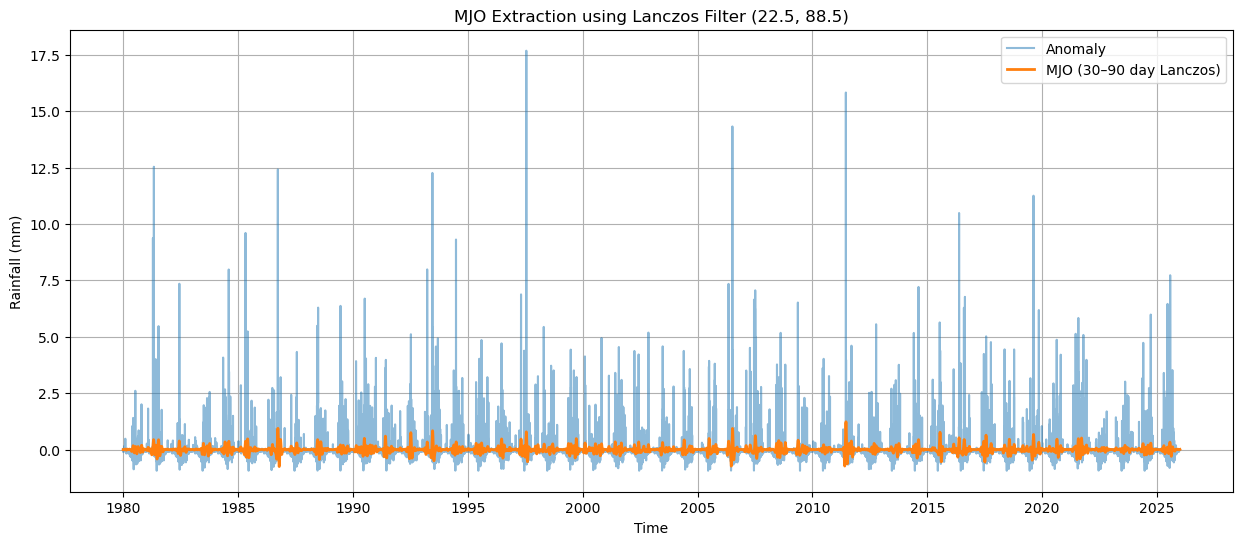

In [5]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve

# ============================================
# PARAMETERS (MJO BAND)
# ============================================
low_period  = 90   # days
high_period = 30   # days
dt = 1            # daily data

# cutoff frequencies
f1 = 1 / low_period
f2 = 1 / high_period

# Lanczos window size (IMPORTANT)
window = 121   # should be odd (recommended 101–201)

# ============================================
# CREATE LANCZOS FILTER
# ============================================
def lanczos_bandpass(window, f1, f2):
    n = (window - 1) // 2
    k = np.arange(-n, n+1)

    h = np.zeros(len(k))

    for i in range(len(k)):
        if k[i] == 0:
            h[i] = 2 * (f2 - f1)
        else:
            h[i] = (np.sin(2*np.pi*f2*k[i]) - np.sin(2*np.pi*f1*k[i])) / (np.pi*k[i])

    # Lanczos sigma factor
    sigma = np.sinc(k / n)

    h = h * sigma
    return h

# create filter weights
weights = lanczos_bandpass(window, f1, f2)

# ============================================
# LOAD ANOMALY DATA
# ============================================
file = r"/mnt/hdd4/A_Nilay/ERA5_Daily_Prep_1980-2026/anomaly.nc"

ds = xr.open_dataset(file).rename({'valid_time': 'time'})
ds = ds.sortby('latitude')

# convert to mm
ds['tp'] = ds['tp'] * 1000

# ============================================
# SELECT GRID POINT
# ============================================
lat = 22.5
lon = 88.5

point = ds.sel(latitude=lat, longitude=lon, method='nearest')

ts = point['tp'].values
time = point['time'].values

# ============================================
# APPLY LANCZOS FILTER
# ============================================
filtered = fftconvolve(ts, weights, mode='same')

# ============================================
# CONVERT TO SERIES
# ============================================
ts_anom = pd.Series(ts, index=time)
ts_mjo  = pd.Series(filtered, index=time)

# ============================================
# PLOT COMPARISON
# ============================================
plt.figure(figsize=(15,6))

plt.plot(ts_anom.index, ts_anom, label="Anomaly", alpha=0.5)
plt.plot(ts_mjo.index, ts_mjo, label="MJO (30–90 day Lanczos)", linewidth=2)

plt.title(f"MJO Extraction using Lanczos Filter ({lat}, {lon})")
plt.xlabel("Time")
plt.ylabel("Rainfall (mm)")
plt.legend()
plt.grid()

plt.show()

# ============================================
# OPTIONAL: ZOOM (IMPORTANT)
# ============================================
# plt.xlim("2000-01-01", "2002-12-31")
# plt.show()

# Creating separate MJO file using Lanczos filter=> 

In [7]:
import xarray as xr
import numpy as np
from scipy.signal import fftconvolve

# ============================================
# PARAMETERS (MJO BAND)
# ============================================
low_period  = 90
high_period = 30

f1 = 1 / low_period
f2 = 1 / high_period

window = 121   # must be odd

# ============================================
# LANCZOS FILTER FUNCTION
# ============================================
def lanczos_bandpass(window, f1, f2):
    n = (window - 1) // 2
    k = np.arange(-n, n+1)

    h = np.zeros(len(k))

    for i in range(len(k)):
        if k[i] == 0:
            h[i] = 2 * (f2 - f1)
        else:
            h[i] = (np.sin(2*np.pi*f2*k[i]) - np.sin(2*np.pi*f1*k[i])) / (np.pi*k[i])

    sigma = np.sinc(k / n)
    return h * sigma

weights = lanczos_bandpass(window, f1, f2)

# ============================================
# LOAD DATA (FIXED CHUNKING)
# ============================================
file = "/mnt/hdd4/A_Nilay/ERA5_Daily_Prep_1980-2026/anomaly.nc"

ds = xr.open_dataset(file)

# rename + sort
ds = ds.rename({'valid_time': 'time'})
ds = ds.sortby('latitude')

# convert to mm
ds['tp'] = ds['tp'] * 1000

# 🔥 IMPORTANT FIX: time must be single chunk
ds = ds.chunk({'time': -1, 'latitude': 50, 'longitude': 50})

# ============================================
# APPLY LANCZOS FILTER
# ============================================
def apply_lanczos(ts):
    return fftconvolve(ts, weights, mode='same')

mjo = xr.apply_ufunc(
    apply_lanczos,
    ds['tp'],
    input_core_dims=[['time']],
    output_core_dims=[['time']],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[float],
    dask_gufunc_kwargs={'allow_rechunk': True}
)

# ============================================
# CREATE DATASET
# ============================================
mjo_ds = xr.Dataset(
    {'tp_mjo': mjo},
    coords=ds.coords
)

# ============================================
# SAVE OUTPUT
# ============================================
output_file = "mjo_lanczos.nc"

print("🚀 Computing and saving MJO dataset...")

mjo_ds.to_netcdf(output_file)

print(f"✅ Done! Saved as {output_file}")

🚀 Computing and saving MJO dataset...
✅ Done! Saved as mjo_lanczos.nc


# Varifying lanczos file=>

In [8]:
import xarray as xr

ds = xr.open_dataset("mjo_lanczos.nc")
print(ds)

<xarray.Dataset> Size: 9GB
Dimensions:    (latitude: 201, longitude: 321, time: 16802)
Coordinates:
  * latitude   (latitude) float64 2kB 0.0 0.25 0.5 0.75 ... 49.5 49.75 50.0
  * longitude  (longitude) float64 3kB 40.0 40.25 40.5 ... 119.5 119.8 120.0
  * time       (time) datetime64[ns] 134kB 1980-01-01 1980-01-02 ... 2025-12-31
Data variables:
    tp_mjo     (latitude, longitude, time) float64 9GB ...


getfattr: /mnt/hdd4/A_Nilay/VS: No such file or directory
getfattr: CODE/mjo_lanczos.nc: No such file or directory


# 1st Plot => Plotting only MJO signals just for checking

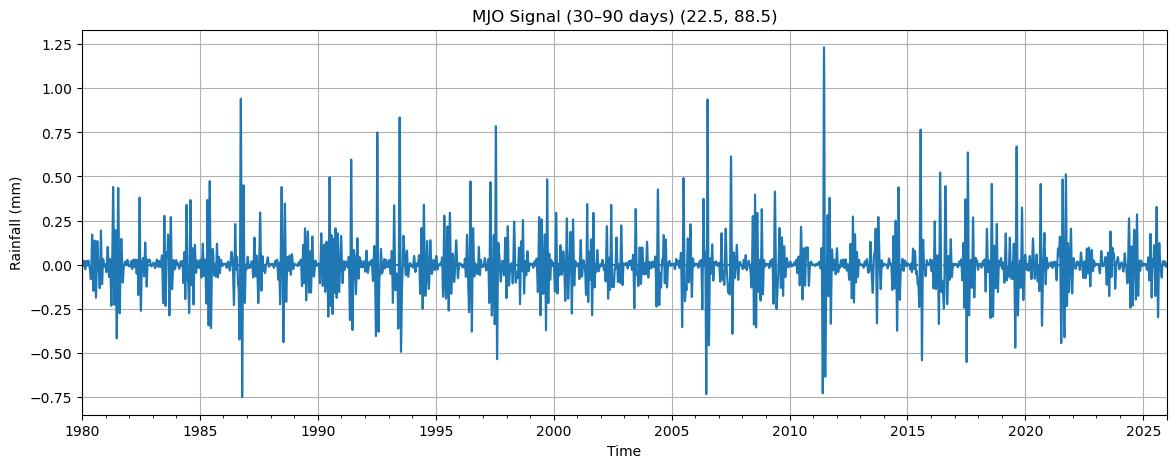

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt

# ============================================
# FILE PATH
# ============================================
mjo_file = r"D:\PHD 2025~\MJO_Server1/mjo_lanczos.nc"

# ============================================
# LOAD DATA
# ============================================
ds = xr.open_dataset(mjo_file)

# sort latitude (just to be safe)
ds = ds.sortby('latitude')

# ============================================
# SELECT GRID POINT
# ============================================
lat = 22.5
lon = 88.5

point = ds.sel(latitude=lat, longitude=lon, method='nearest')

# ============================================
# CONVERT TO SERIES
# ============================================
ts_mjo = point['tp_mjo'].to_series()

# ============================================
# PLOT
# ============================================
plt.figure(figsize=(14,5))
ts_mjo.plot()

plt.title(f"MJO Signal (30–90 days) ({lat}, {lon})")
plt.xlabel("Time")
plt.ylabel("Rainfall (mm)")
plt.axhline(0, linestyle='--')
plt.grid()

plt.show()

# OPTIONAL ZOOM
# plt.xlim("2000-01-01", "2002-12-31")
# plt.show()

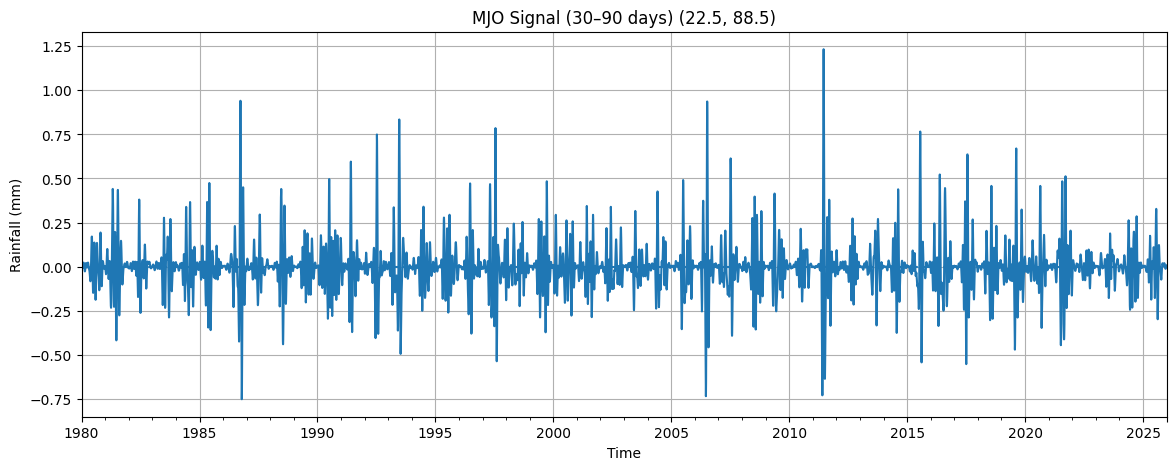

In [2]:
import xarray as xr
import matplotlib.pyplot as plt

# ============================================
# FILE PATH
# ============================================
mjo_file = r"E:\IIT KGP 2025\SERVER_1/mjo_lanczos.nc"

# ============================================
# LOAD DATA
# ============================================
ds = xr.open_dataset(mjo_file)

# sort latitude (just to be safe)
ds = ds.sortby('latitude')

# ============================================
# SELECT GRID POINT
# ============================================
lat = 22.5
lon = 88.5

point = ds.sel(latitude=lat, longitude=lon, method='nearest')

# ============================================
# CONVERT TO SERIES
# ============================================
ts_mjo = point['tp_mjo'].to_series()

# ============================================
# PLOT
# ============================================
plt.figure(figsize=(14,5))
ts_mjo.plot()

plt.title(f"MJO Signal (30–90 days) ({lat}, {lon})")
plt.xlabel("Time")
plt.ylabel("Rainfall (mm)")
plt.axhline(0, linestyle='--')
plt.grid()

plt.show()

# OPTIONAL ZOOM
# plt.xlim("2000-01-01", "2002-12-31")
# plt.show()

# 2nd plot => Annomally comparison=>

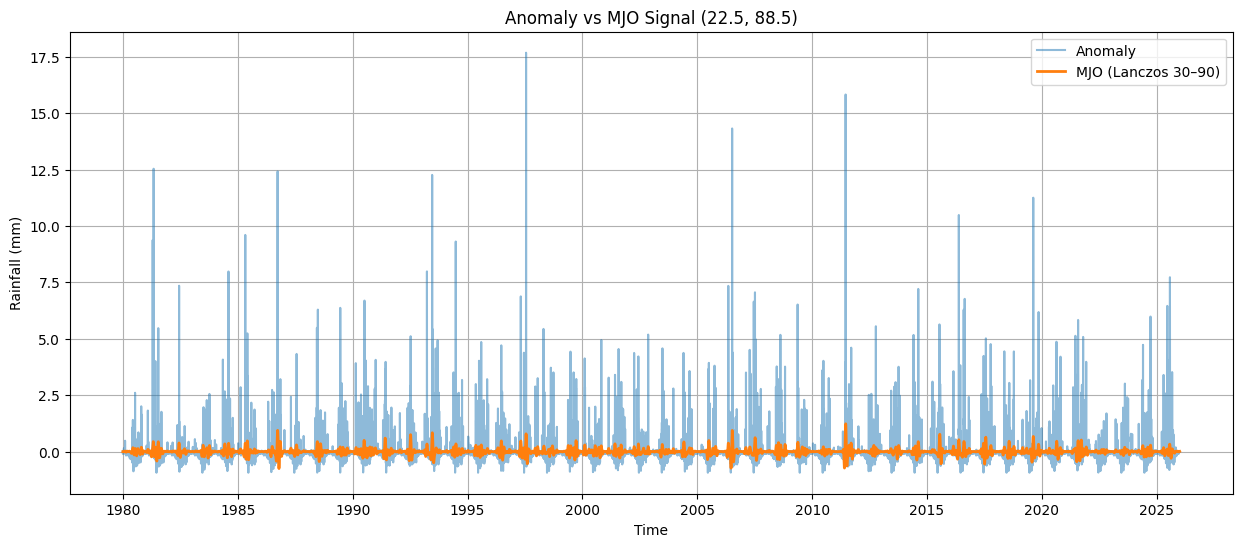

In [3]:
import xarray as xr
import matplotlib.pyplot as plt

# ============================================
# FILE PATHS
# ============================================
mjo_file  = r"E:\IIT KGP 2025\SERVER_1\mjo_lanczos.nc"
anom_file = r"E:\IIT KGP 2025\SERVER_1\anomaly.nc"

# ============================================
# LOAD DATA
# ============================================
mjo  = xr.open_dataset(mjo_file)
anom = xr.open_dataset(anom_file).rename({'valid_time': 'time'})

# sort latitude
mjo  = mjo.sortby('latitude')
anom = anom.sortby('latitude')

# convert anomaly to mm
anom['tp'] = anom['tp'] * 1000

# ============================================
# SELECT GRID POINT
# ============================================
lat = 22.5
lon = 88.5

mjo_point  = mjo.sel(latitude=lat, longitude=lon, method='nearest')
anom_point = anom.sel(latitude=lat, longitude=lon, method='nearest')

# ============================================
# CONVERT TO SERIES
# ============================================
ts_mjo  = mjo_point['tp_mjo'].to_series()
ts_anom = anom_point['tp'].to_series()

# ============================================
# PLOT COMPARISON
# ============================================
plt.figure(figsize=(15,6))

plt.plot(ts_anom.index, ts_anom, label="Anomaly", alpha=0.5)
plt.plot(ts_mjo.index, ts_mjo, label="MJO (Lanczos 30–90)", linewidth=2)

plt.title(f"Anomaly vs MJO Signal ({lat}, {lon})")
plt.xlabel("Time")
plt.ylabel("Rainfall (mm)")
plt.legend()
plt.grid()

plt.show()

# OPTIONAL ZOOM (VERY IMPORTANT)
# plt.xlim("2000-01-01", "2002-12-31")
# plt.show()